<a href="https://colab.research.google.com/github/carolina-andrade-mx/PySpark-Linear-Regression-with-MLlib/blob/main/PySpark_Linear_Regression_with_MLlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#California Housing Price Linear Regression Analysis

##Introduction

This project applies PySpark and its MLlib framework to explore and model housing price patterns in California. Using the housing.csv dataset, the analysis begins with an examination of the structure and distribution of key variables, including median_income and median_house_value, both of which exhibit substantial variability and right‑skewed behavior.

The exploratory phase incorporates descriptive statistics, frequency tables, histograms, kurtosis measures, scatterplots, and correlation analysis to identify relevant patterns in the data. Building on these insights, two linear regression models are developed using MLlib: a simple regression with median income as the predictor, and a multiple regression that incorporates additional features such as population, total rooms, and housing median age. Model performance is assessed through RMSE and R² to evaluate predictive accuracy and explanatory strength.

Overall, the project combines data exploration, visualization, and MLlib‑based modeling to outline the main factors associated with housing values in California and to illustrate an analytical workflow in PySpark.

##Importing Data

For this step please import data from "housing.csv" file attached to the repository.

In [1]:
#!pip install pyspark
import pyspark

In [2]:
# CODE TO START SPARK SESSION
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName('House Analysis').getOrCreate()

In [3]:
from google.colab import files
uploaded = files.upload()

Saving housing.csv to housing.csv


In [4]:
df = spark.read.csv('housing.csv', header=True, inferSchema=True)

## Data exploration

In [5]:
#1. Spark DataFrame
df.show(5)
df.printSchema()

+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+
|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|ocean_proximity|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+
|  -122.23|   37.88|              41.0|      880.0|         129.0|     322.0|     126.0|       8.3252|          452600.0|       NEAR BAY|
|  -122.22|   37.86|              21.0|     7099.0|        1106.0|    2401.0|    1138.0|       8.3014|          358500.0|       NEAR BAY|
|  -122.24|   37.85|              52.0|     1467.0|         190.0|     496.0|     177.0|       7.2574|          352100.0|       NEAR BAY|
|  -122.25|   37.85|              52.0|     1274.0|         235.0|     558.0|     219.0|       5.6431|          341300.0|       NEAR BAY|
|  -122.25|   37.85|              

In [6]:

rows = df.count()
cols = len(df.columns)

print(f"This data base contains {rows} rows and {cols} columns")

This data base contains 20640 rows and 10 columns


In [7]:

df.columns

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value',
 'ocean_proximity']

In [8]:
#2 Describe numerical columns

df.describe().show()

+-------+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+---------------+
|summary|          longitude|          latitude|housing_median_age|       total_rooms|    total_bedrooms|        population|        households|    median_income|median_house_value|ocean_proximity|
+-------+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+------------------+---------------+
|  count|              20640|             20640|             20640|             20640|             20433|             20640|             20640|            20640|             20640|          20640|
|   mean|-119.56970445736388| 35.63186143410869|28.639486434108527|2635.7630813953488| 537.8705525375618|1425.4767441860465| 499.5396802325581|3.870671002907009|206855.81690891474|           NULL|
| stddev| 2.003

## Descriptive Statistics

Measures of central tendency and dispersion for Median Income (X) and Median House Value (Y)

In [9]:
from pyspark.sql.functions import mean, variance, stddev, max, min, col

variables = ["median_income", "median_house_value"]

for var in variables:
    print(f"\n===== {var.upper()} =====")

    # Mean
    mean_val = df.select(mean(var)).first()[0]

    # Median (approximate)
    median_val = df.approxQuantile(var, [0.5], 0.01)[0]


    # Variance
    var_val = df.select(variance(var)).first()[0]

    # Standard deviation
    std_val = df.select(stddev(var)).first()[0]

    # Range
    min_val = df.select(min(var)).first()[0]
    max_val = df.select(max(var)).first()[0]
    range_val = max_val - min_val

    # Print results
    print("Measures of central Tendency")
    print(f"Mean: {mean_val}")
    print(f"Median: {median_val}")
    print("\nMeasures of dispersion")
    print(f"Variance: {var_val}")
    print(f"Standard Deviation: {std_val}")
    print(f"Range: {range_val}")



===== MEDIAN_INCOME =====
Measures of central Tendency
Mean: 3.870671002907009
Median: 3.5208

Measures of dispersion
Variance: 3.6093225599765097
Standard Deviation: 1.899821717945268
Range: 14.5002

===== MEDIAN_HOUSE_VALUE =====
Measures of central Tendency
Mean: 206855.81690891474
Median: 178600.0

Measures of dispersion
Variance: 13316148163.035263
Standard Deviation: 115395.61587441381
Range: 485002.0


**Median Income**

The mean (3.87) is slightly higher than the median (3.52), indicating a right‑skewed distribution with some higher-income values pulling the average upward.
The dispersion measures show moderate variability (SD ≈ 1.90) and a very wide range (14.50), suggesting the presence of extreme high-income values.

**Median House Value**

The mean (206,856) is well above the median (178,600), showing a strong right skew driven by high-value properties.
The dispersion is very large (SD ≈ 115,396 and a range of 485,002), indicating substantial variability and the presence of high-value outliers in the housing market.

The extremely large variance and standard deviation of median_house_value are expected, as housing prices in California vary widely across regions. The distribution is strongly right‑skewed, with high‑value properties creating a very large spread. This level of dispersion is normal for this dataset and reflects real market heterogeneity.

##Frequency table of Median Income



In [10]:
import pandas as pd

print("Median_Income is expressed in tens of thousands of dollars.")
df_pd = df.select("median_income").toPandas()
bins = [0, 2, 4, 6, 8, 10, 20]
freq_table = pd.cut(df_pd["median_income"], bins=bins).value_counts().sort_index()
freq_df = freq_table.reset_index()
freq_df.columns = ["Interval", "Frequency"]
freq_df

# Creating intervals
#.cut() in pandas is a very useful function that divides a numerical
#variable into intervals (bins) and assigns each value to its corresponding class.
#It is ideal for building frequency tables by intervals or for creating histograms.



Median_Income is expressed in tens of thousands of dollars.


,Interval,Frequency
0,"(0, 2]",2457
1,"(2, 4]",10096
2,"(4, 6]",5725
3,"(6, 8]",1672
4,"(8, 10]",382
5,"(10, 20]",308


## Histogram


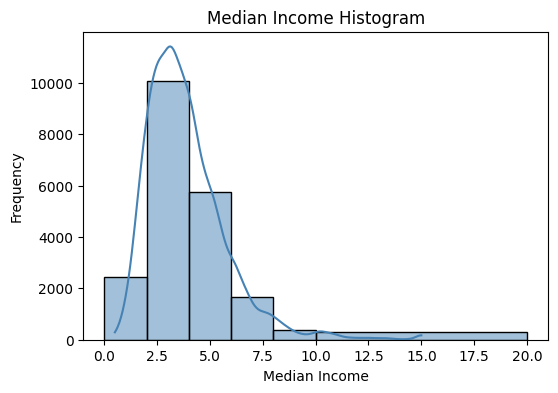

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seaborn creates histograms and KDE (distribution curves) in a single line.
plt.figure(figsize=(6,4))

sns.histplot(
    df_pd["median_income"],         # x axis median income
    bins=[0, 2, 4, 6, 8, 10, 20],   # y axis frequency
    kde=True,                       # distribution curve
    color="steelblue",
    edgecolor="black"
)

plt.title("Median Income Histogram")
plt.xlabel("Median Income")
plt.ylabel("Frequency")
plt.show()


The histogram shows that median income (in tens of thousands of dollars) is heavily concentrated at the lower end of the distribution, with most observations falling between 20,000 and 30,000 dollars, and progressively fewer cases as income increases. The right‑skewed shape indicates that high‑income values are much less common.

##Leptokurtic kurtosis = 4.9


In [12]:
kurtosis_value = df_pd["median_income"].kurt()
print(kurtosis_value)


4.952524101991511


A kurtosis of 4.9 indicates a strongly leptokurtic distribution. This means the variable has a very sharp peak, heavy tails, and a higher presence of extreme values compared to a normal distribution. In short: the data are highly concentrated in the center but with many outliers on the sides.

##Frequency table of Median House Value

In [13]:
df_pd = df.select("median_house_value").toPandas()
bins = [0, 100000, 200000, 300000, 400000, 500000, 600000]
freq_table = pd.cut(df_pd["median_house_value"], bins=bins).value_counts().sort_index()
freq_df = freq_table.reset_index()
freq_df.columns = ["Interval", "Frequency"]
freq_df


,Interval,Frequency
0,"(0, 100000]",3658
1,"(100000, 200000]",8273
2,"(200000, 300000]",4873
3,"(300000, 400000]",2092
4,"(400000, 500000]",779
5,"(500000, 600000]",965


##Histogram

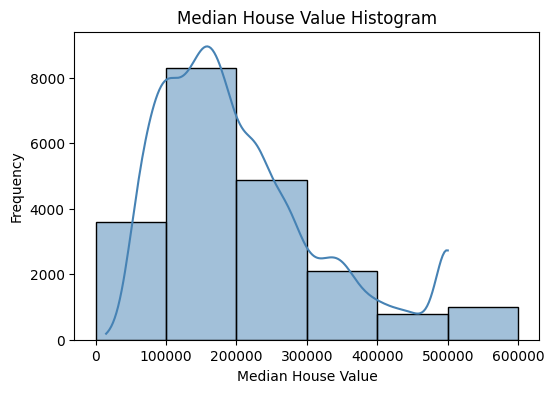

In [14]:
plt.figure(figsize=(6,4))

sns.histplot(
    df_pd["median_house_value"],  # x axis median income
    bins=[0, 100000, 200000, 300000, 400000, 500000, 600000],   # y axis frequency
    kde=True,                      # curva de distribución
    color="steelblue",
    edgecolor="black"
)

plt.title("Median House Value Histogram")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()


The histogram shows that median house values are mostly concentrated in the 100,000–200,000 dollars range, with frequencies dropping sharply as values increase. The distribution is right‑skewed, indicating that high‑value homes are much less common.

##Kurtosis =0.32

In [15]:
kurtosis_value = df_pd["median_house_value"].kurt()
print(kurtosis_value)


0.3278702429465872



A kurtosis of 0.32 indicates a distribution that is slightly more heavy‑tailed than normal, but still very close to a typical bell shape. It suggests a mild presence of extreme values, without indicating an unusually peaked or highly outlier‑prone distribution.


## Scatterplot

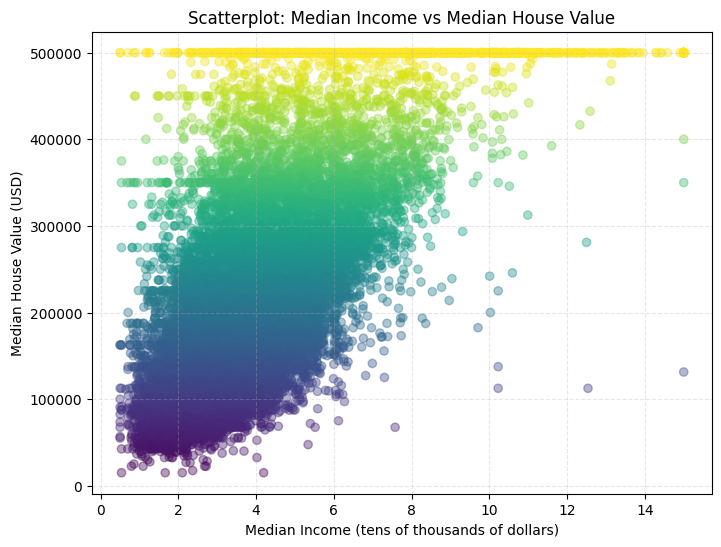

In [16]:
df_pd = df.select("median_income", "median_house_value").toPandas()

plt.figure(figsize=(8,6))
plt.scatter(df_pd["median_income"],
            df_pd["median_house_value"],
            c=df_pd["median_house_value"], # color according to value
            cmap="viridis",
            alpha=0.4
)

plt.xlabel("Median Income (tens of thousands of dollars)")
plt.ylabel("Median House Value (USD)")
plt.title("Scatterplot: Median Income vs Median House Value")

plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


The scatterplot shows a positive relationship between median income (in tens of thousands of dollars) and median house value. As income increases, house values generally rise as well, though many points cluster near the upper value limit, reflecting the dataset’s capped maximum house value as shown in the box below.

In [17]:
from pyspark.sql import functions as F

df.agg(F.max("median_house_value")).show()

+-----------------------+
|max(median_house_value)|
+-----------------------+
|               500001.0|
+-----------------------+



## Pearson's R


In [18]:
from pyspark.sql.functions import corr

df.select(corr("median_income", "median_house_value")).show()
#con pandas
#df_pd["median_income"].corr(df_pd["median_house_value"])


+---------------------------------------+
|corr(median_income, median_house_value)|
+---------------------------------------+
|                     0.6880752079585459|
+---------------------------------------+



A correlation of 0.68 means that California neighborhoods with higher median income tend to have higher house values.


#Simple Linear Regression
The regression line is the line that best represents the linear correlation between two quantitative variables in a scatterplot.
The best line is the one that minimizes the sum of squared residuals.

**Y = B0 + B1*X**

where:

* Y is median house value

* X is median income

* B0 is the intercept, the value of Y when X = 0

* B1 is the slope, how much Y changes when X increases by 1 unit




In [19]:
#1. Aseemble the features
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["median_income"],   # simple regression → 1 column
    outputCol="features"
)

df_vec = assembler.transform(df)


In [20]:
#Split of data
train_data, test_data = df_vec.randomSplit([0.8, 0.2], seed=42)

In [21]:
#2. Create the LinearRegression object
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(
    featuresCol="features",
    labelCol="median_house_value"
)


In [22]:
#Fitting the model
model = lr.fit(train_data)


In [23]:
#Extracting coefficients
slope = model.coefficients[0]
intercept = model.intercept
print(intercept)
print(slope)

44430.07235739138
41833.66197158722


The equation for the simple regression is as follows:

Y = 44430.07 + 41833.66*X

For every 1‑unit increase in median_income (i.e., every 10,000 increase in median household income), the predicted median house value increases by approximately 41,834.

In [24]:
# Make predictions
#Predictions are the value of Y estimated by the model,given x from the original dataframe
predictions = model.transform(test_data)
predictions.show()

+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+--------+------------------+
|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|ocean_proximity|features|        prediction|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+--------+------------------+
|   -124.3|   41.84|              17.0|     2677.0|         531.0|    1244.0|     456.0|       3.0313|          103600.0|     NEAR OCEAN|[3.0313]|171240.45189186372|
|  -124.23|   40.54|              52.0|     2694.0|         453.0|    1152.0|     435.0|       3.0806|          106700.0|     NEAR OCEAN|[3.0806]|173302.85142706297|
|  -124.23|   41.75|              11.0|     3159.0|         616.0|    1343.0|     479.0|       2.4805|           73200.0|     NEAR OCEAN|[2.4805]| 148198.4708779135|
|  -

In [25]:
# Making prediction of median hose value if median income = 7.500

nuevo = spark.createDataFrame([(7.500,)], ["median_income"])
nuevo_vec = assembler.transform(nuevo)
pred_nuevo = model.transform(nuevo_vec)
pred_nuevo.show()


+-------------+--------+-----------------+
|median_income|features|       prediction|
+-------------+--------+-----------------+
|          7.5|   [7.5]|358182.5371442955|
+-------------+--------+-----------------+



##Scatterplot with fitted linear regression line

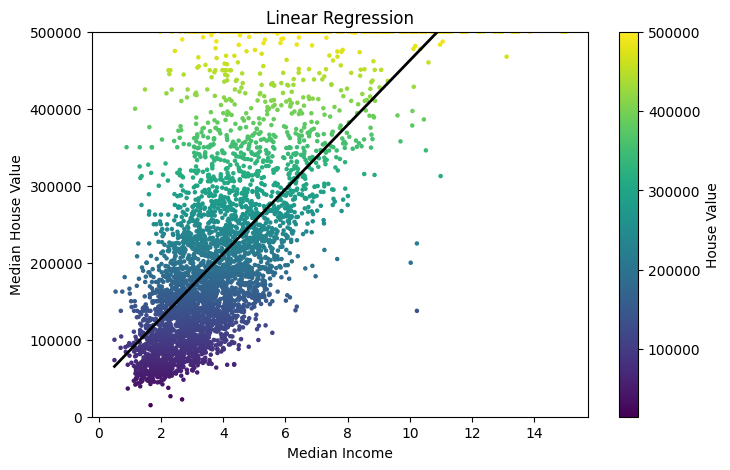

In [26]:
pdf = predictions.select("median_income", "median_house_value", "prediction").toPandas()

# 5. Sorting
pdf = pdf.sort_values("median_income")

# 6. Chart
plt.figure(figsize=(8,5))

# Scatter with viridis
plt.scatter(
    pdf["median_income"],
    pdf["median_house_value"],
    c=pdf["median_house_value"],
    cmap="viridis",
    s=5
)

# Linear Regression
plt.plot(
    pdf["median_income"],
    pdf["prediction"],
    color="black",
    linewidth=2
)

# Labels
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Linear Regression")

# Color Bar
plt.colorbar(label="House Value")

plt.ylim(0, 500000)

plt.show()


##Evaluating model performance using RMSE

**RegressionEvaluator()**
RegressionEvaluator() is a PySpark tool used to measure how well a regression model performs.
It evaluates the model using metrics such as:
- RMSE
- MAE
- R²

**RMSE — Root Mean Squared Error (squared errors)**
RMSE tells you how much your model is wrong on average, in the same units as your target variable.It takes all the differences between the actual value and the predicted value.It squares them so that larger errors carry more weight.



In [27]:
from pyspark.ml.evaluation import RegressionEvaluator

evaluator = RegressionEvaluator(
    labelCol="median_house_value",
    predictionCol="prediction",
    metricName="rmse"
)

rmse = evaluator.evaluate(predictions)
print("RMSE:", rmse)


RMSE: 84678.21816199702


##R2



In [28]:
from pyspark.ml.evaluation import RegressionEvaluator

evaluator_r2 = RegressionEvaluator(
    labelCol="median_house_value",
    predictionCol="prediction",
    metricName="r2"
)

r2 = evaluator_r2.evaluate(predictions)
print("R²:", r2)

R²: 0.48175253348721847


## Model Performance Summary
The simple linear regression model shows:
- RMSE ≈ 84,678
On average, the model’s predictions differ from the true median house values by about $84,678.
- R² ≈ 0.48
The model explains about 47% of the variance in house values, meaning it captures some of the relationship but leaves more than half unexplained.


#Multiple Linear Regression


Y = B0 + B1X1 + B2X2 + .....+ BnXn

Dependent variable:

* Y = Median house value

Explanatory variables:

 * B1 Median Income

 * B2 Population

 * B3 Total rooms

 * B4 Housing median age

In [29]:
#1. Aseemble the features
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["median_income","population","housing_median_age","total_rooms"],   #packing
    outputCol="features"
)

df_vec = assembler.transform(df)

#2.Split into train and test
train_data, test_data = df_vec.randomSplit([0.8, 0.2], seed=42)

#3.Create the LinearRegression object
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(
    featuresCol="features",
    labelCol="median_house_value"
)

#4. Fit the model

model = lr.fit(train_data)

#5.Extract coefficients
feature_names = ["median_income","population","housing_median_age","total_rooms"]

print("Intercept:", model.intercept)

for name, coef in zip(feature_names, model.coefficients):
    print(f"{name}: {coef}")


#Predictions
predictions = model.transform(test_data)
predictions.show()


Intercept: -18057.909555775313
median_income: 41303.902924252696
population: -12.60831662699289
housing_median_age: 1991.617457897199
total_rooms: 9.660938774107096
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+--------------------+------------------+
|longitude|latitude|housing_median_age|total_rooms|total_bedrooms|population|households|median_income|median_house_value|ocean_proximity|            features|        prediction|
+---------+--------+------------------+-----------+--------------+----------+----------+-------------+------------------+---------------+--------------------+------------------+
|   -124.3|   41.84|              17.0|     2677.0|         531.0|    1244.0|     456.0|       3.0313|          103600.0|     NEAR OCEAN|[3.0313,1244.0,17...|151181.69537706982|
|  -124.23|   40.54|              52.0|     2694.0|         453.0|    1152.0|     435.0|       3.0806|          106700.0|  

## Model Performance


In [30]:

# RMSE
evaluator_rmse = RegressionEvaluator(
    labelCol="median_house_value",
    predictionCol="prediction",
    metricName="rmse"
)
rmse = evaluator_rmse.evaluate(predictions)
print("RMSE:", rmse)

# R²
evaluator_r2 = RegressionEvaluator(
    labelCol="median_house_value",
    predictionCol="prediction",
    metricName="r2"
)
r2 = evaluator_r2.evaluate(predictions)
print("R²:", r2)


RMSE: 81409.46796719551
R²: 0.5209910819095386


- RMSE ≈ 81,409
The model’s average prediction error is about $81K, which is still high but lower than before.
- R² ≈ 0.52
The model explains about 52% of the variation in house prices, meaning it captures roughly half of the real pattern.


##Comparing simple and multiple regression

Compared to the simple regression model, the multiple regression model performs better overall. The RMSE decreases from approximately 84K to 81K, indicating that the average prediction error becomes smaller. Additionally, the R² increases from about 0.48 to 0.52, meaning the model now explains a larger share of the variation in house prices. This improvement shows that including additional predictors, such as population, housing median age, and total rooms, enhances both the accuracy and explanatory power of the model.


##Conclusion
The results of this analysis highlight several important insights about the California housing market and the performance of linear regression models applied to this dataset using PySpark’s MLlib library.

First, both median_income and median_house_value display strong right‑skewed distributions, reflecting the presence of high‑income and high‑value outliers. Despite this variability, the two variables show a substantial positive correlation (≈ 0.68), indicating that neighborhoods with higher median income tend to have higher housing prices.

The simple linear regression model, implemented through MLlib, confirms this relationship by explaining approximately 48% of the variation in house values. However, the RMSE of around 84,678 indicates considerable prediction error due to the heterogeneity of the housing market. When additional predictors are included in the multiple linear regression model, performance improves modestly: RMSE decreases to about 81,409 and R² increases to roughly 0.52. This suggests that variables such as population, total rooms, and housing median age contribute additional explanatory value, although median income remains the dominant predictor.

Overall, the analysis shows that linear regression provides a clear and interpretable baseline for understanding general trends in the data. The workflow implemented with PySpark and MLlib demonstrates an efficient approach to data preparation, feature assembly, model training, and evaluation.

In [32]:
spark.stop()